In [2]:
import os
import sqlite3 as sql
import pandas as pd

In [3]:
#read file paths and concatenate the four review files into one file
product_info = "raw data/product_info.csv"
review_1 = "raw data/reviews_0-250.csv"
review_2 = "raw data/reviews_250-500.csv"
review_3 = "raw data/reviews_500-750.csv"
review_4 = "raw data/reviews_750-1250.csv"
review_5 = "raw data/reviews_1250-end.csv"
review_path = [review_1, review_2, review_3, review_4, review_5]


In [4]:
#Subsetting Stage
#subsetting by skin care only using the primary category column in the product info file
products = pd.read_csv(product_info)   
skincare_products = products[products["primary_category"].astype(str).str.strip().eq("Skincare")].copy()
skincare_products
#define a product and review key as the product id to match the product id's in the subsetted product file with the review files
product_key = "product_id"
review_key = "product_id" 
skincare_id = set(skincare_products[product_key].dropna().unique())
#filter these id's in the review file
filtered_reviews = []
for p in review_path:
    r = pd.read_csv(p,low_memory=False)
    filtered_reviews.append(r[r[review_key].isin(skincare_id)])
skincare_reviews = pd.concat(filtered_reviews, ignore_index=True)
#check the length of each file
print("Skincare products:", len(skincare_products))
print("Skincare reviews:", len(skincare_reviews))

Skincare products: 2420
Skincare reviews: 1094411


In [5]:
#Reaction Keyword Signal and Raw Score Stage
import re
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans

#giving each review a score based on keywords that relate to dryness, acne and irritation
product_ID_col = "product_id"
review_text_col = "review_text"   
rating_col = "rating"             
recommend_col = "recommend"      
raw_ingredients = "ingredients"   

#using lexicon NLP and creating a dictionary with a list of words that relate to each concern
LEXICON = {
    "acne": [
        "acne","breakout","breakouts","pimple","pimples","zit","zits",
        "whitehead","whiteheads","blackhead","blackheads",
        "clog","clogged","comedone","comedones","congestion","congested",
        "bumpy","bumps","purge","purging"
    ],
    "dryness": [
        "dry","dryer","dryness","dehydrated","dehydration","tight","tightness",
        "flaky","flake","flaking","peeling","peel","cracked","cracking",
        "parched","rough","roughness"
    ],
    "irritation": [
        "irritation","irritated","irritating","red","redness","inflamed",
        "burn","burning","stinging","sting","itch","itchy","rash",
        "hives","swelling","swollen","sensitive","sensitivity","reacted","reaction"
    ]
}

NEGATIONS = {"no","not","never","none","without","hardly","barely"} #define a dictionary of negations

def normalize_text(s): #normalizing the text by cleaning and converting to lowercase
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def tokenize(s):
    # keeps words and contractions like didn't etc.
    return re.findall(r"[a-z]+'?[a-z]+|[a-z]+", normalize_text(s))

def negation_window(tokens, idx, window=3): #making sure if a negation appears before N tokens before the term, it does not count it since it is a positive review and has no affect.
    # True if a negation appears within N tokens before the term
    start = max(0, idx - window)
    ctx = tokens[start:idx]
    for w in ctx:
        if w in NEGATIONS or w.endswith("n't"):
            return True
    return False

def concern_scores_for_review(text):
    tokens = tokenize(text)
    scores = {k: 0.0 for k in LEXICON.keys()}
    if not tokens:
        return scores

    for i, tok in enumerate(tokens): #goes through the reviews and adds +1 for every review that contains and particular signa;
        for concern, terms in LEXICON.items():
            if tok in terms and not negation_window(tokens, i, window=3):
                scores[concern] += 1.0
    return scores

#apply this to the reviews
scores_df = skincare_reviews[review_text_col].fillna("").apply(concern_scores_for_review).apply(pd.Series)
scores_df = scores_df.rename(columns={c: f"{c}_raw" for c in scores_df.columns})

skincare_reviews_scored = pd.concat([skincare_reviews.reset_index(drop=True), scores_df], axis=1)

skincare_reviews_scored[[review_text_col, "acne_raw", "dryness_raw", "irritation_raw"]].head() #output a dataframe with raw scores per category per review

,review_text,acne_raw,dryness_raw,irritation_raw
0,I use this with the Nudestix “Citrus Clean Bal...,0.0,0.0,0.0
1,I bought this lip mask after reading the revie...,0.0,0.0,0.0
2,My review title says it all! I get so excited ...,0.0,2.0,0.0
3,I’ve always loved this formula for a long time...,0.0,0.0,0.0
4,"If you have dry cracked lips, this is a must h...",0.0,2.0,0.0


In [ ]:
#Weighted Score Stage
#output weighted concern scores per review
def soft_weight(rating=None, recommend=None):
    w = 1.0
    
    if rating is not None and not pd.isna(rating): #rating criteria, weighs a higher rated review less than a lowrr rated review
        # uses rating=1 -> 1.0, rating=5 -> 0.2
        w *= (6 - float(rating)) / 5.0 #normalizes the rating
    
    if recommend is not None and not pd.isna(recommend): #recommendation criteria, weighs a non-recommended product 25% more than a recommended one.
        w *= 1.25 if int(recommend) == 0 else 1.0
    
    return float(w)

skincare_reviews_scored["review_weight"] = skincare_reviews_scored.apply(
    lambda r: soft_weight(
        rating=r.get(rating_col, None),
        recommend=r.get(recommend_col, None)
    ),
    axis=1
)

# Weighted concern scores
for c in LEXICON.keys():
    skincare_reviews_scored[f"{c}_w"] = skincare_reviews_scored[f"{c}_raw"] * skincare_reviews_scored["review_weight"]

skincare_reviews_scored[["review_weight","acne_w","dryness_w","irritation_w"]].head() #outputs the weighted scores per review

,review_weight,acne_w,dryness_w,irritation_w
0,0.2,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,0.2,0.0,0.4,0.0
3,0.2,0.0,0.0,0.0
4,0.2,0.0,0.4,0.0


In [7]:
#Product level aggregation stage
eps = 1e-9

product_concerns = skincare_reviews_scored.groupby(product_ID_col).agg( #uses the number of review per product to get the weighted scores per product
    n_reviews=(review_text_col, "count"),
    total_weight=("review_weight", "sum"),
    acne_sum=("acne_w", "sum"),
    dryness_sum=("dryness_w", "sum"),
    irritation_sum=("irritation_w", "sum"),
).reset_index()

#Convert sums to rates and normalize across products
#Convert sums to stabilized rates
#lambda_prior prevents extreme rates for products with very few reviews
lambda_prior = 5

product_concerns["acne_rate"] = (
    product_concerns["acne_sum"] /
    (product_concerns["total_weight"] + lambda_prior)
)

product_concerns["dryness_rate"] = (
    product_concerns["dryness_sum"] /
    (product_concerns["total_weight"] + lambda_prior)
)

product_concerns["irritation_rate"] = (
    product_concerns["irritation_sum"] /
    (product_concerns["total_weight"] + lambda_prior)
)

#Also outputs the dominant concern
rate_cols = ["acne_rate","dryness_rate","irritation_rate"]
product_concerns["dominant_concern"] = product_concerns[rate_cols].idxmax(axis=1).str.replace("_rate","")

product_concerns.head()

,product_id,n_reviews,total_weight,acne_sum,dryness_sum,irritation_sum,acne_rate,dryness_rate,irritation_rate,dominant_concern
0,P107306,253,99.6,4.6,6.8,21.6,0.043977,0.065010,0.206501,irritation
1,P114902,1529,483.2,578.8,153.2,190.2,1.185580,0.313806,0.389594,acne
2,P12045,1684,525.2,30.8,139.0,123.4,0.058091,0.262165,0.232742,dryness
3,P122651,200,59.4,9.8,33.6,19.2,0.152174,0.521739,0.298137,dryness
4,P122661,810,237.8,49.6,79.2,54.8,0.204283,0.326194,0.225700,dryness


In [8]:
#Clustering Stage

from sklearn.preprocessing import StandardScaler

#Features used for clustering
cluster_features = ["acne_rate", "dryness_rate", "irritation_rate"]

X = product_concerns[cluster_features].values #creating a feature matrix

#Scale so concerns contribute equally
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)  # we test k 2 to 10

results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Xs)
    
    inertia = km.inertia_  # also calculate WCSS (within-cluster sum of squares) for evaluation
    sil_score = silhouette_score(Xs, labels)
    
    results.append({ #calculate sihoutte score for evaluation, which measures separation between clusters
        "k": k,
        "inertia": inertia,
        "silhouette": sil_score
    })

results_df = pd.DataFrame(results)
results_df

,k,inertia,silhouette
0,2,4690.354431,0.399345
1,3,3450.925784,0.405577
2,4,2709.081975,0.394877
3,5,2169.698916,0.347442
4,6,1851.824923,0.344448
5,7,1633.565315,0.358028
6,8,1452.603793,0.325875
7,9,1333.362861,0.320661
8,10,1244.982640,0.317079


In [9]:
# Evaluating K Stage 
#Test different K values and show cluster profiles
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    product_concerns[f'cluster_k{k}'] = km.fit_predict(Xs)
    
    k_metrics = product_concerns.groupby(f'cluster_k{k}')[
        ['acne_rate', 'dryness_rate', 'irritation_rate']
    ].mean()
    

    print(f"K = {k}")
    print(k_metrics)
    #We choose best k = 3, explanation in report

K = 2
            acne_rate  dryness_rate  irritation_rate
cluster_k2                                          
0            0.338501      0.334681         0.333832
1            0.076980      0.124696         0.119495
K = 3
            acne_rate  dryness_rate  irritation_rate
cluster_k3                                          
0            0.194032      0.353332         0.323644
1            0.077346      0.111186         0.114430
2            0.949595      0.197204         0.267424
K = 4
            acne_rate  dryness_rate  irritation_rate
cluster_k4                                          
0            0.248848      0.245813         0.551967
1            0.079371      0.095875         0.113688
2            0.993965      0.201148         0.261583
3            0.159846      0.373760         0.210001
K = 5
            acne_rate  dryness_rate  irritation_rate
cluster_k5                                          
0            0.264321      0.321325         0.744404
1            0.048573 

In [ ]:
#Choose final K
FINAL_K = 3
product_concerns["cluster_id"] = product_concerns[f"cluster_k{FINAL_K}"].astype(int)

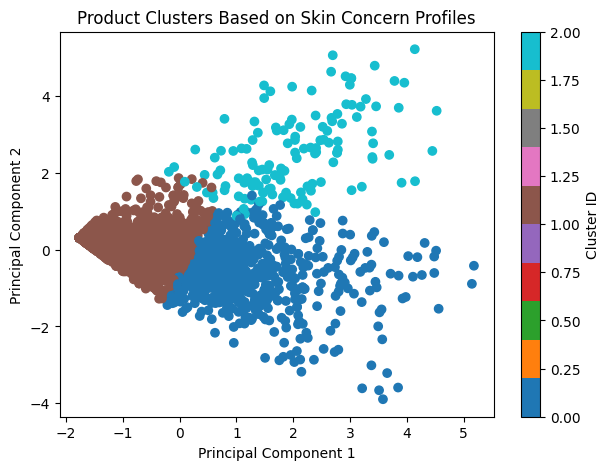

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xs)

plot_df = product_concerns.copy()
plot_df["PC1"] = X_pca[:, 0]
plot_df["PC2"] = X_pca[:, 1]

# Make the figure and draw the scatter
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster_id"],
    cmap="tab10"
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Product Clusters Based on Skin Concern Profiles")
fig.colorbar(sc, ax=ax, label="Cluster ID")


fig.savefig("outputs/figures/pca_clusters.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

In [12]:
from sklearn.cluster import AgglomerativeClustering

#Hierarchical clustering to compare clusters
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

product_concerns["cluster_hier"] = hierarchical.fit_predict(Xs)

#Compare cluster profiles with the skin concenr reactions
cluster_profiles_hier = (
    product_concerns
    .groupby("cluster_hier")[[
        "acne_rate",
        "dryness_rate",
        "irritation_rate",
        "n_reviews"
    ]]
    .mean()
)

print("Hierarchical Cluster Profiles:")
display(cluster_profiles_hier)

Hierarchical Cluster Profiles:


,acne_rate,dryness_rate,irritation_rate,n_reviews
cluster_hier,,,,
0,0.191113,0.386385,0.361131,771.017544
1,0.087324,0.134132,0.129573,344.564876
2,0.800250,0.213129,0.277880,698.845304


In [13]:
#Cluster evaluation stage for K means
cluster_profiles = (
    product_concerns
    .groupby("cluster_id")[[
        "acne_rate",
        "dryness_rate",
        "irritation_rate",
        "n_reviews"
    ]]
    .mean()
    .sort_index()
)

cluster_profiles["dominant_concern"] = (
    cluster_profiles[[
        "acne_rate",
        "dryness_rate",
        "irritation_rate"
    ]]
    .idxmax(axis=1)
    .str.replace("_rate","")
)

cluster_profiles


,acne_rate,dryness_rate,irritation_rate,n_reviews,dominant_concern
cluster_id,,,,,
0,0.194032,0.353332,0.323644,739.583875,dryness
1,0.077346,0.111186,0.114430,306.064872,irritation
2,0.949595,0.197204,0.267424,607.060150,acne


In [14]:
#Identify and label clusters
cluster_label_map = cluster_profiles["dominant_concern"].to_dict()
cluster_label_map

{0: 'dryness', 1: 'irritation', 2: 'acne'}

In [15]:
#Mapping common ingredients stage

import pandas as pd
import numpy as np
import ast
import re

product_ID_col = "product_id"
CLUSTER_COL = "cluster_id"
raw_ingredients = "ingredients"

def parse_list_string(x): #cleaning the data and representing the ingredients as a python list
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return v
    except Exception:
        pass
    return [s]

def split_items(item): 
    parts = re.split(r",\s*(?![^()]*\))", str(item))
    return [p.strip() for p in parts if p.strip()]

def clean_token(s): #stripping the data of certain spaces and characters
    s = str(s).lower().strip()
    s = re.sub(r"\(.*?\)", " ", s)
    s = re.sub(r"\b\d+(\.\d+)?\s*%\b", " ", s)
    s = re.sub(r"[^a-z0-9\s\/\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = s.replace("aqua/water/eau", "water").replace("water/aqua/eau", "water").replace("aqua water eau", "water") #replacing water alike ingredients as just water
    return s

cluster_products = skincare_products[[product_ID_col, raw_ingredients]].merge( #keeping products that exist in both datasets where skincare products gives us product info and product concerns gives us cluster info
    product_concerns[[product_ID_col, CLUSTER_COL]],
    on=product_ID_col,
    how="inner"
)

cluster_products["ingredient_items"] = cluster_products[raw_ingredients].apply(parse_list_string) #ensure each product has a list of ingredients

df_long = ( #convert to a longer format where we have one row per ingredient item
    cluster_products[[product_ID_col, CLUSTER_COL, "ingredient_items"]]
    .explode("ingredient_items")
    .rename(columns={"ingredient_items": "inci_item"})
    .dropna(subset=["inci_item"])
)

df_long["ingredient_list"] = df_long["inci_item"].apply(split_items) #split the long format into each ingredients separated by commas

df_long = (
    df_long[[product_ID_col, CLUSTER_COL, "ingredient_list"]] #repeat the same process for one row per ingredient item
    .explode("ingredient_list")
    .rename(columns={"ingredient_list": "ingredient"})
    .dropna(subset=["ingredient"])
)

df_long["ingredient"] = df_long["ingredient"].apply(clean_token) #clean ingredient strings more and remove certain common keywords
df_long = df_long[df_long["ingredient"].str.len() >= 2]
df_long = df_long[~df_long["ingredient"].isin({"", "and", "or", "may contain", "contains"})]
TOP_N = 20 #we want the top 20 ingredients per cluster

top_common = ( #returns a dataframe with the top common ingredients per cluster
    df_long
    .drop_duplicates([CLUSTER_COL, product_ID_col, "ingredient"])
    .groupby([CLUSTER_COL, "ingredient"])
    .size()
    .reset_index(name="n_products")
    .sort_values([CLUSTER_COL, "n_products"], ascending=[True, False])
    .groupby(CLUSTER_COL)
    .head(TOP_N)
    .reset_index(drop=True)
)

tables_by_cluster = {}
for cid, t in top_common.groupby(CLUSTER_COL):
    t = t.sort_values("n_products", ascending=False).reset_index(drop=True)
    tables_by_cluster[cid] = t
    display(t)
    t.to_csv(
        f"outputs/tables/top_ingredients_cluster_{cid}.csv",
        index=False
    )


<unknown>:1: SyntaxWarning: invalid escape sequence '\A'
<unknown>:1: SyntaxWarning: invalid escape sequence '\A'


,cluster_id,ingredient,n_products
0,0,glycerin,599
1,0,water,531
2,0,phenoxyethanol,415
3,0,butylene glycol,334
4,0,tocopherol,326
5,0,citric acid,315
6,0,ethylhexylglycerin,300
7,0,xanthan gum,277
8,0,propanediol,275
9,0,sodium hyaluronate,273


,cluster_id,ingredient,n_products
0,1,glycerin,1038
1,1,water,844
2,1,phenoxyethanol,727
3,1,butylene glycol,656
4,1,tocopherol,605
5,1,citric acid,571
6,1,sodium hyaluronate,538
7,1,propanediol,504
8,1,caprylyl glycol,500
9,1,xanthan gum,498


,cluster_id,ingredient,n_products
0,2,water,94
1,2,glycerin,82
2,2,phenoxyethanol,70
3,2,sodium hydroxide,56
4,2,butylene glycol,54
5,2,disodium edta,44
6,2,salicylic acid,42
7,2,citric acid,41
8,2,propanediol,39
9,2,xanthan gum,38


In [ ]:
#saving these outputs 
skincare_reviews_scored.to_csv(
    "outputs/tables/review_reaction_scores.csv",
    index=False
)
product_concerns.to_csv(
    "outputs/tables/product_concern_profiles.csv",
    index=False
)
results_df.to_csv(
    "outputs/tables/k_sweep_metrics.csv",
    index=False
)
cluster_profiles.to_csv(
    "outputs/tables/cluster_profiles.csv"
)
plt.savefig(
    "outputs/figures/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [17]:
#Regression model - Supervised Part 

import numpy as np
import pandas as pd

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


ingredients_by_product = ( #groups the ingredients of each product and makes it into a list
    df_long
    .groupby("product_id")["ingredient"]
    .apply(list)
    .reset_index(name="ingredient_list")
)

model_df = ingredients_by_product.merge( #merge the ingredient data with the cluster data from our unsupervised part
    product_concerns[[
        "product_id",
        "cluster_id"
    ]],
    on="product_id",
    how="inner"
)


mlb = MultiLabelBinarizer() #use MultiLabelBinarizer to convert the ingredients lists into feature vectors that are binary ingredient vectors
X = mlb.fit_transform(model_df["ingredient_list"])
feature_names = mlb.classes_
n_unique_ingredients = len(feature_names)
print("Unique ingredients:", n_unique_ingredients)

Y = model_df["cluster_id"] #define our prediction target

print("Feature matrix shape:", X.shape)


X_train, X_test, y_train, y_test = train_test_split( #now we train and test, we use a 80/20 split
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

log_reg = LogisticRegression( #training our logistic regression model
    solver="lbfgs",
    max_iter=3000
)
log_reg.fit(X_train, y_train)


y_pred = log_reg.predict(X_test) #now run this on the testing data

print("Accuracy:", accuracy_score(y_test, y_pred)) #print our results of accuracy and metric
print(classification_report(y_test, y_pred))
from sklearn.metrics import f1_score, balanced_accuracy_score

cluster_probs = log_reg.predict_proba(X_test) #predicts the probability of each reaction occuring

prob_df = pd.DataFrame(
    cluster_probs,
    columns=[f"P(cluster_{c})" for c in log_reg.classes_]
)

display(prob_df.head())

Unique ingredients: 6294
Feature matrix shape: (2224, 6294)
Accuracy: 0.6539325842696629
              precision    recall  f1-score   support

           0       0.53      0.47      0.50       150
           1       0.71      0.78      0.74       269
           2       0.67      0.38      0.49        26

    accuracy                           0.65       445
   macro avg       0.64      0.55      0.58       445
weighted avg       0.65      0.65      0.65       445



,P(cluster_0),P(cluster_1),P(cluster_2)
0,0.588591,0.300696,0.110713
1,0.426027,0.521679,0.052294
2,0.903404,0.089092,0.007505
3,0.792192,0.205955,0.001853
4,0.017880,0.981822,0.000299


In [18]:
import pandas as pd #building the prediction function

def predict_concern(ingredient_list):

    clean_ingredients = [
        str(i).lower().strip()
        for i in ingredient_list
        if str(i).strip() != ""
    ]

    X_input = mlb.transform([clean_ingredients])
    probs = log_reg.predict_proba(X_input)[0]

    labels = [
        cluster_label_map.get(c, f"cluster_{c}")
        for c in log_reg.classes_
    ]

    return pd.Series(probs, index=labels)

In [19]:
#General test: 
predict_concern([
    "water",
    "niacinamide",
    "salicylic acid"
    "glycerin"
])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['salicylic acidglycerin'] will be ignored
  warnings.warn(


dryness       0.417308
irritation    0.451193
acne          0.131499
dtype: float64

In [22]:
#Test with Clear Improvement Active Charcoal Mask to Clear Pores

predict_concern([
    "water",
    "myrtus communis",
    "kaolin",
    "bentonite",
    "butylene glycol",
    "xanthan gum"
])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['myrtus communis'] will be ignored
  warnings.warn(


dryness       0.702382
irritation    0.153647
acne          0.143971
dtype: float64

In [21]:
#Test with Supergoop Unseen Sunscreen SPF 40
predict_concern([
    "isododecane",
    "dimethicone",
    "tocopherol",
    "octocrylene",
    "caprylyl glycol"
])

dryness       0.173907
irritation    0.793191
acne          0.032902
dtype: float64